## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage

from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.datasets import load_wine
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    calinski_harabasz_score, adjusted_rand_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


## 3. Load & Explore the Dataset

In [2]:
wine = load_wine()
X_raw = pd.DataFrame(wine.data, columns=wine.feature_names)
y_true = wine.target
class_names = wine.target_names  # ['class_0', 'class_1', 'class_2']

print('Shape:', X_raw.shape)
print('Classes:', class_names)
print('Samples per class:', np.bincount(y_true))
X_raw.describe().round(2)


Shape: (178, 13)
Classes: ['class_0' 'class_1' 'class_2']
Samples per class: [59 71 48]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


## 4. Exploratory Data Analysis



In [3]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
ev = pca.explained_variance_ratio_
print(f'Variance explained: PC1={ev[0]:.1%}, PC2={ev[1]:.1%}, total={sum(ev):.1%}')


Variance explained: PC1=36.2%, PC2=19.2%, total=55.4%


In [4]:
PALETTE = {-1:'#555555', 0:'#E64646', 1:'#2196F3', 2:'#FF9800'}
MARKERS = {-1:'x', 0:'o', 1:'s', 2:'^'}

def plot_clusters(ax, X2d, labels, title, class_names_map=None, alpha=0.75):
    for lbl in np.unique(labels):
        mask = labels == lbl
        color = PALETTE.get(lbl, '#888888')
        marker = MARKERS.get(lbl, 'o')
        name = 'Noise' if lbl == -1 else (class_names_map[lbl] if class_names_map else f'Cluster {lbl}')
        ax.scatter(X2d[mask,0], X2d[mask,1], c=color, marker=marker,
                   s=40, alpha=alpha, edgecolors='white', linewidths=0.4, label=name)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel(f'PC1 ({ev[0]:.1%} var)', fontsize=9)
    ax.set_ylabel(f'PC2 ({ev[1]:.1%} var)', fontsize=9)
    ax.legend(fontsize=8, framealpha=0.7)
    ax.grid(True, alpha=0.2)


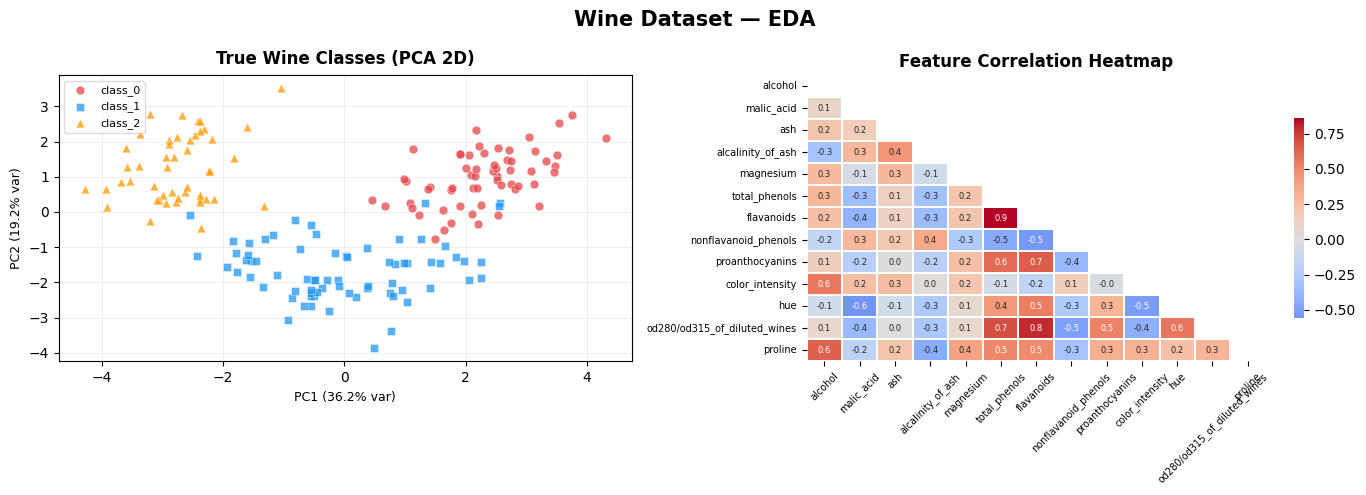

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Wine Dataset — EDA', fontsize=15, fontweight='bold')

# True class structure
cn_map = {i: n for i, n in enumerate(class_names)}
plot_clusters(axes[0], X_pca, y_true, 'True Wine Classes (PCA 2D)', class_names_map=cn_map)

# Feature correlation heatmap
corr = X_raw.corr().round(2)
mask_upper = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask_upper, ax=axes[1], cmap='coolwarm', center=0,
            annot=True, fmt='.1f', annot_kws={'size': 6},
            linewidths=0.3, cbar_kws={'shrink': 0.7})
axes[1].set_title('Feature Correlation Heatmap', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=7)
axes[1].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.show()


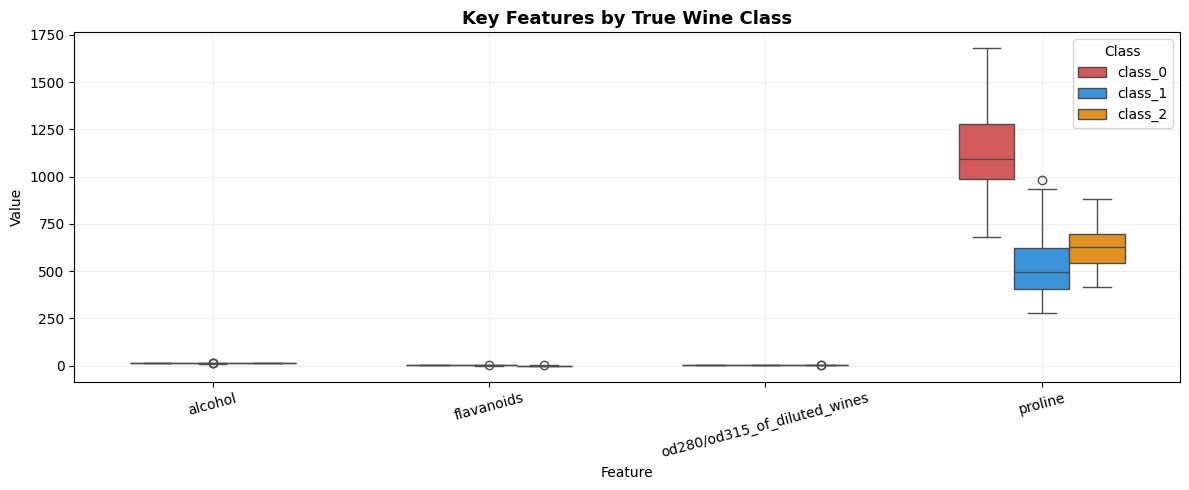

In [6]:
# Boxplots of key features by true class
top_feats = ['alcohol', 'flavanoids', 'od280/od315_of_diluted_wines', 'proline']
df_plot = X_raw[top_feats].copy()
df_plot['Class'] = [class_names[t] for t in y_true]
df_melted = df_plot.melt(id_vars='Class', var_name='Feature', value_name='Value')

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_melted, x='Feature', y='Value', hue='Class',
            ax=ax, palette=['#E64646','#2196F3','#FF9800'], width=0.6)
ax.set_title('Key Features by True Wine Class', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=15)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


## DBSCAN

## 5. Effect of `eps` on DBSCAN

/tmp/ipykernel_8547/1903823265.py:10: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X2d[mask,0], X2d[mask,1], c=color, marker=marker,
/tmp/ipykernel_8547/1903823265.py:10: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X2d[mask,0], X2d[mask,1], c=color, marker=marker,
/tmp/ipykernel_8547/1903823265.py:10: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X2d[mask,0], X2d[mask,1], c=color, marker=marker,
/tmp/ipykernel_8547/1903823265.py:10: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker 

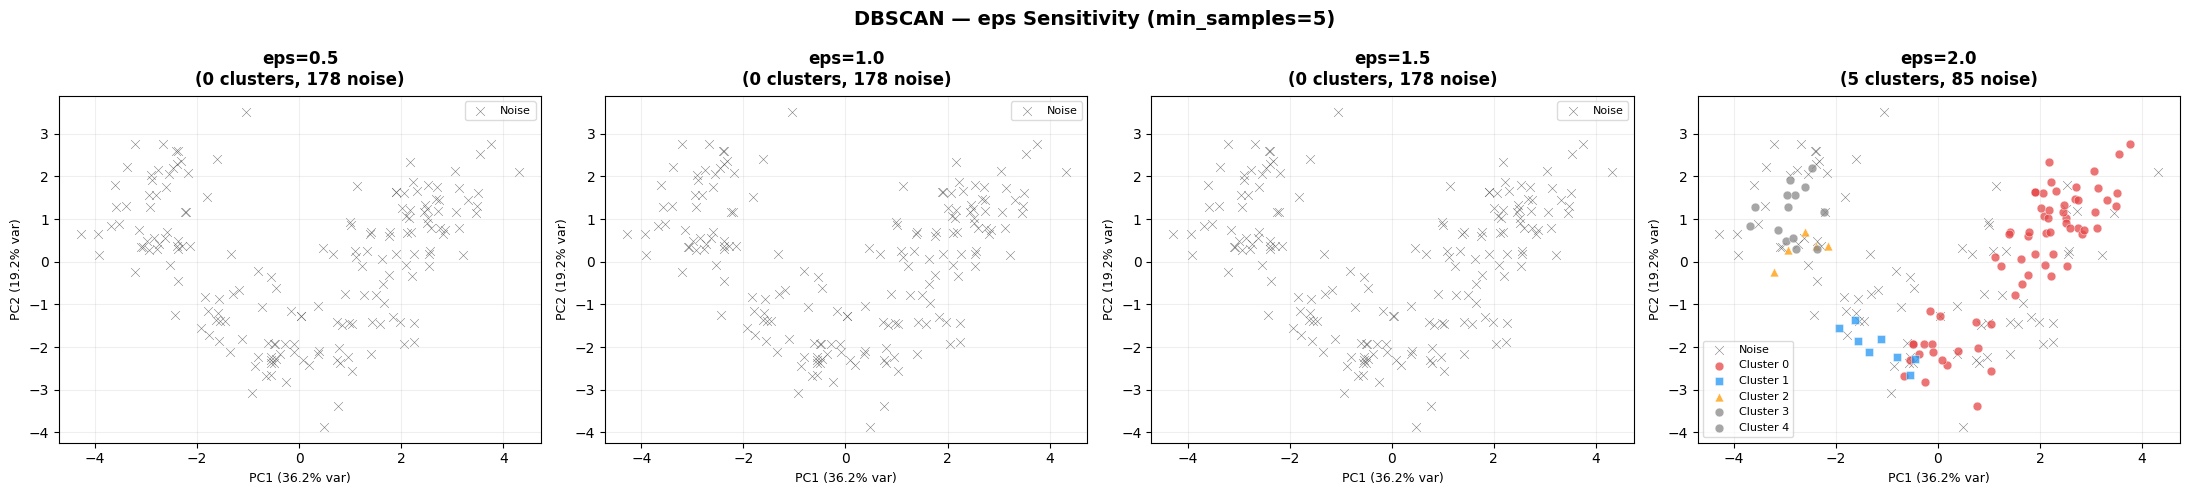

In [7]:
eps_values = [0.5, 1.0, 1.5, 2.0]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('DBSCAN — eps Sensitivity (min_samples=5)', fontsize=14, fontweight='bold')

for ax, eps in zip(axes, eps_values):
    labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X)
    n_cl   = len(set(labels)) - (1 if -1 in labels else 0)
    noise  = int(np.sum(labels == -1))
    plot_clusters(ax, X_pca, labels, f'eps={eps}\n({n_cl} clusters, {noise} noise)')

plt.tight_layout()
plt.show()


## 6. Evaluation Metrics (same as lab)

In [8]:
def evaluate_clustering(X_full, y_true, y_pred, model_name):
    result = {'Model': model_name}
    n_clusters = len(set(y_pred)) - (1 if -1 in y_pred else 0)
    result['Clusters']  = n_clusters
    result['Noise pts'] = int(np.sum(y_pred == -1)) if -1 in y_pred else 0

    mask = y_pred != -1
    X_e, y_e, yt_e = X_full[mask], y_pred[mask], y_true[mask]

    if len(X_e) > 1 and len(np.unique(y_e)) > 1:
        result['Silhouette ↑']        = round(silhouette_score(X_e, y_e), 3)
        result['Davies-Bouldin ↓']     = round(davies_bouldin_score(X_e, y_e), 3)
        result['Calinski-Harabasz ↑'] = round(calinski_harabasz_score(X_e, y_e), 3)
    else:
        result['Silhouette ↑'] = result['Davies-Bouldin ↓'] = result['Calinski-Harabasz ↑'] = float('nan')

    result['ARI ↑'] = round(adjusted_rand_score(yt_e, y_e), 3)
    return result

print('Metric helper defined.')


Metric helper defined.


## 7. DBSCAN vs KMeans vs Agglomerative

/tmp/ipykernel_8547/1903823265.py:10: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X2d[mask,0], X2d[mask,1], c=color, marker=marker,


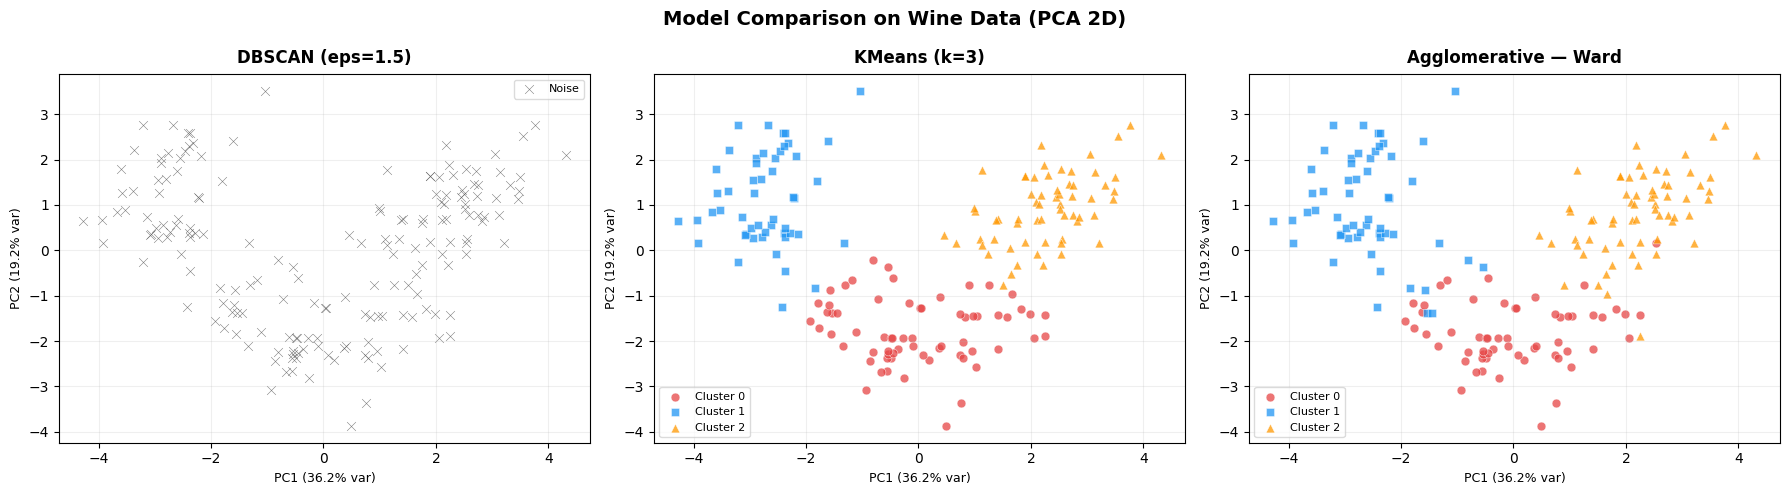

In [9]:
db_best  = DBSCAN(eps=1.5, min_samples=5).fit_predict(X)
kmeans   = KMeans(n_clusters=3, random_state=42, n_init=15).fit_predict(X)
agg_ward = AgglomerativeClustering(n_clusters=3, linkage='ward').fit_predict(X)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Comparison on Wine Data (PCA 2D)', fontsize=14, fontweight='bold')

plot_clusters(axes[0], X_pca, db_best,  'DBSCAN (eps=1.5)')
plot_clusters(axes[1], X_pca, kmeans,   'KMeans (k=3)')
plot_clusters(axes[2], X_pca, agg_ward, 'Agglomerative — Ward')

plt.tight_layout()
plt.show()


In [10]:
results_main = pd.DataFrame([
    evaluate_clustering(X, y_true, db_best,  'DBSCAN (eps=1.5)'),
    evaluate_clustering(X, y_true, kmeans,   'KMeans (k=3)'),
    evaluate_clustering(X, y_true, agg_ward, 'Agglomerative Ward'),
])
results_main


,Model,Clusters,Noise pts,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑,ARI ↑
0,DBSCAN (eps=1.5),0,178,NaN,NaN,NaN,1.000
1,KMeans (k=3),3,0,0.285,1.389,70.940,0.897
2,Agglomerative Ward,3,0,0.277,1.419,67.647,0.790


## Agglomerative Clustering


## 8. Linkage Comparison

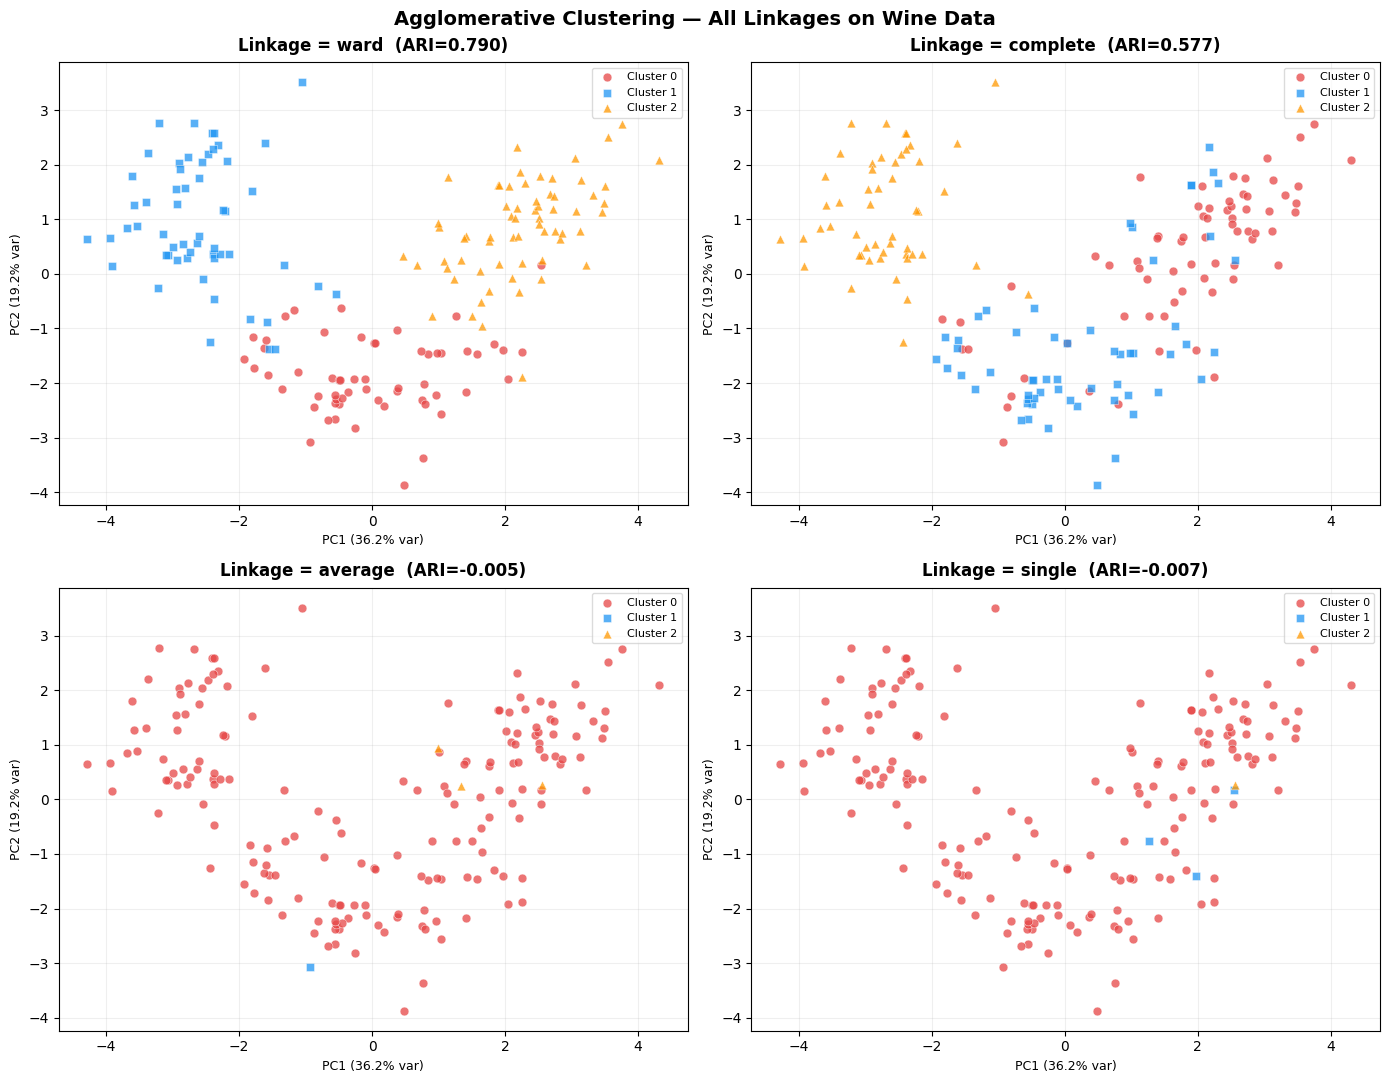

In [11]:
linkages = ['ward', 'complete', 'average', 'single']

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Agglomerative Clustering — All Linkages on Wine Data', fontsize=14, fontweight='bold')

for ax, lnk in zip(axes.ravel(), linkages):
    labels = AgglomerativeClustering(n_clusters=3, linkage=lnk).fit_predict(X)
    ari = adjusted_rand_score(y_true, labels)
    plot_clusters(ax, X_pca, labels, f'Linkage = {lnk}  (ARI={ari:.3f})')

plt.tight_layout()
plt.show()


In [12]:
rows = []
for lnk in linkages:
    labels = AgglomerativeClustering(n_clusters=3, linkage=lnk).fit_predict(X)
    rows.append(evaluate_clustering(X, y_true, labels, f'Agglomerative ({lnk})'))

linkage_results = pd.DataFrame(rows)
linkage_results


,Model,Clusters,Noise pts,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑,ARI ↑
0,Agglomerative (ward),3,0,0.277,1.419,67.647,0.790
1,Agglomerative (complete),3,0,0.204,1.896,48.990,0.577
2,Agglomerative (average),3,0,0.158,1.030,4.031,-0.005
3,Agglomerative (single),3,0,0.183,0.911,4.062,-0.007


## 9. Dendrogram — Ward Linkage



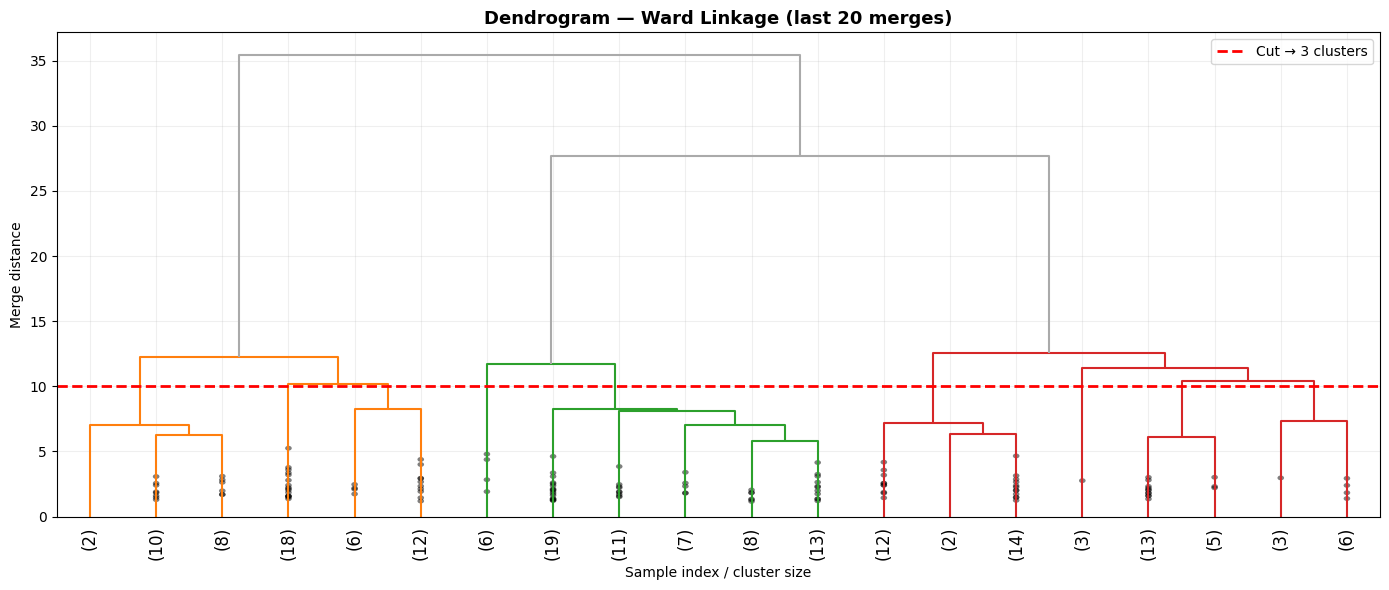

In [13]:
Z = scipy_linkage(X, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=20, leaf_rotation=90,
           color_threshold=0.7 * max(Z[:, 2]),
           above_threshold_color='#AAAAAA', show_contracted=True)
ax.set_title('Dendrogram — Ward Linkage (last 20 merges)', fontsize=13, fontweight='bold')
ax.set_xlabel('Sample index / cluster size', fontsize=10)
ax.set_ylabel('Merge distance', fontsize=10)
ax.axhline(y=10, color='red', linestyle='--', linewidth=2, label='Cut → 3 clusters')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


## 10. Full Metrics Dashboard — All Models

In [14]:
all_models = {
    'DBSCAN (eps=1.5)':       db_best,
    'KMeans (k=3)':           kmeans,
    'Agglomerative Ward':     AgglomerativeClustering(n_clusters=3, linkage='ward').fit_predict(X),
    'Agglomerative Complete': AgglomerativeClustering(n_clusters=3, linkage='complete').fit_predict(X),
    'Agglomerative Average':  AgglomerativeClustering(n_clusters=3, linkage='average').fit_predict(X),
    'Agglomerative Single':   AgglomerativeClustering(n_clusters=3, linkage='single').fit_predict(X),
}

all_results = pd.DataFrame([
    evaluate_clustering(X, y_true, pred, name)
    for name, pred in all_models.items()
])
all_results


,Model,Clusters,Noise pts,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑,ARI ↑
0,DBSCAN (eps=1.5),0,178,NaN,NaN,NaN,1.000
1,KMeans (k=3),3,0,0.285,1.389,70.940,0.897
2,Agglomerative Ward,3,0,0.277,1.419,67.647,0.790
3,Agglomerative Complete,3,0,0.204,1.896,48.990,0.577
4,Agglomerative Average,3,0,0.158,1.030,4.031,-0.005
5,Agglomerative Single,3,0,0.183,0.911,4.062,-0.007


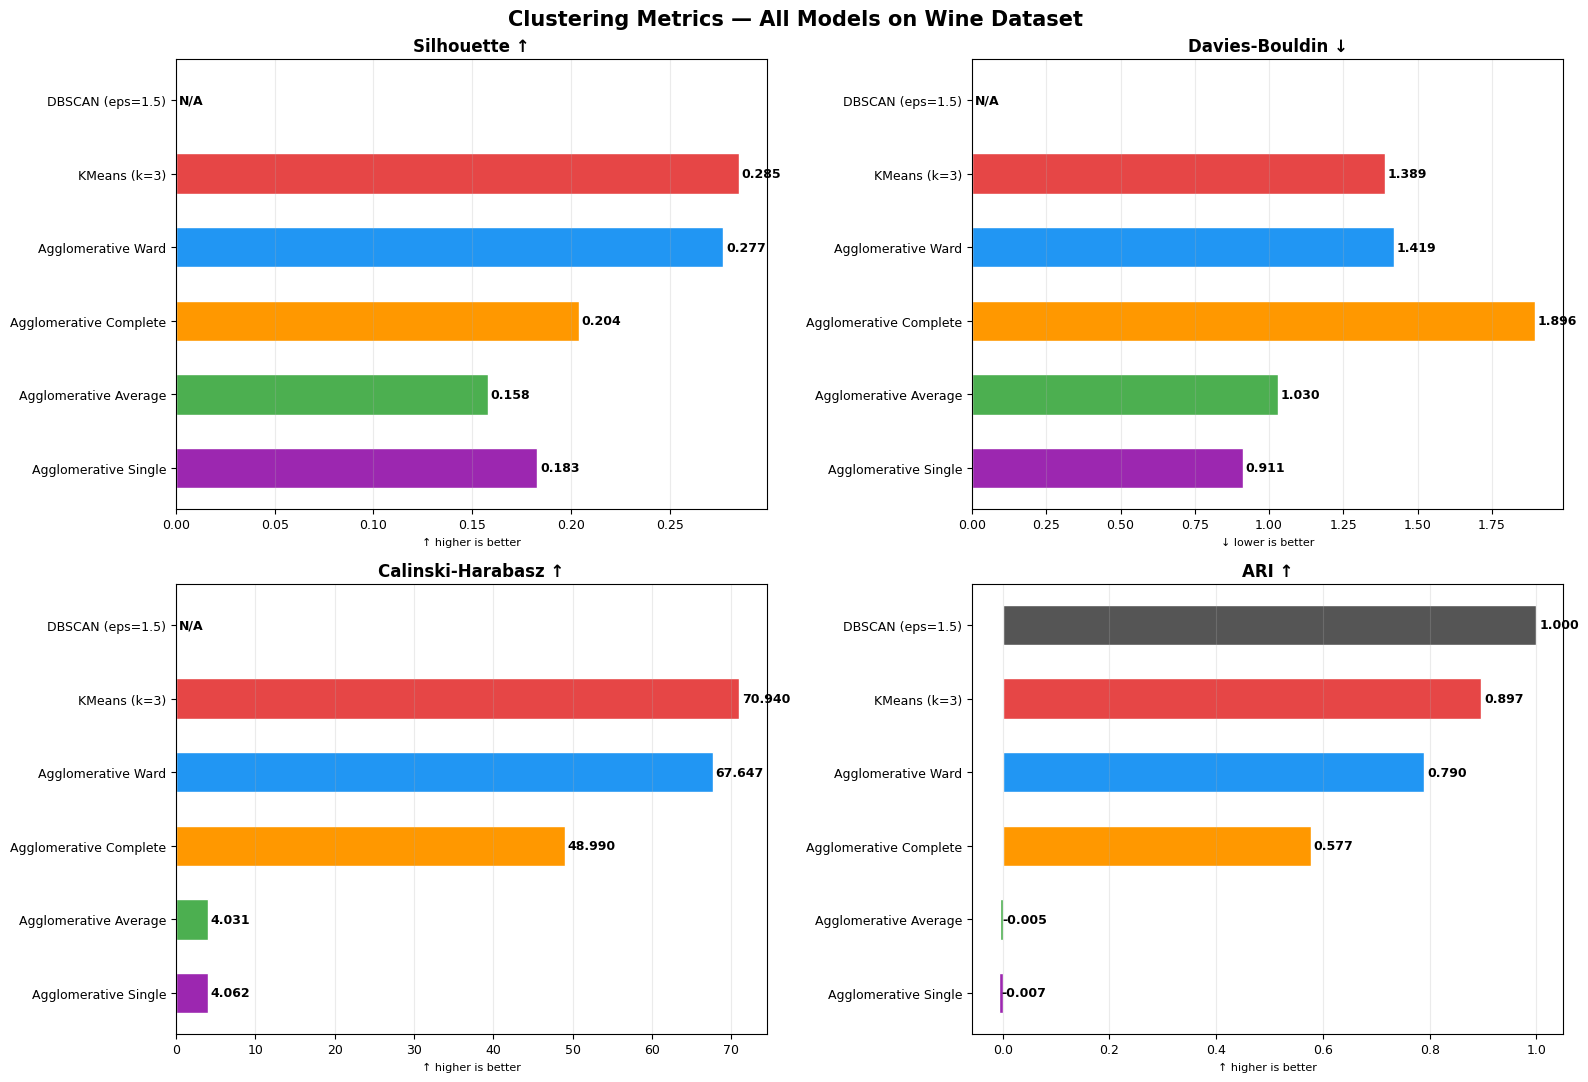

In [15]:
metrics = ['Silhouette ↑', 'Davies-Bouldin ↓', 'Calinski-Harabasz ↑', 'ARI ↑']
colors_bar = ['#555555','#E64646','#2196F3','#FF9800','#4CAF50','#9C27B0']

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Clustering Metrics — All Models on Wine Dataset', fontsize=15, fontweight='bold')

for ax, metric in zip(axes.ravel(), metrics):
    vals = all_results[metric].fillna(0)
    bars = ax.barh(all_results['Model'], vals, color=colors_bar, edgecolor='white', height=0.55)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    for bar, val in zip(bars, all_results[metric]):
        label = f'{val:.3f}' if not (isinstance(val, float) and (val != val)) else 'N/A'
        ax.text(bar.get_width() + 0.005 * max(vals), bar.get_y() + bar.get_height()/2,
                label, va='center', fontsize=9, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.25, axis='x')
    ax.tick_params(labelsize=9)
    ax.set_xlabel('↑ higher is better' if '↑' in metric else '↓ lower is better', fontsize=8)

plt.tight_layout()
plt.show()
